In [1]:
import sys
sys.path.insert(0, '..')

from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import re

from src.data import (
    load_and_prepare, get_username_mappings,
    load_standings, load_model_predictions,
)
from src.simulation import (
    build_player_pool, build_player_pool_score,
    run_simulation, run_simulation_score, build_results,
)
from src.portfolio import (
    build_portfolio, run_portfolio_mc, run_portfolio_mc_score, pnl_summary,
    run_payoff_matrix, portfolio_kelly,
    compute_hedge_correlations, show_best_hedges, kalshi_order_price,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_colwidth', 300)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
df_standings = load_standings()

In [ ]:
CUT_PLAYERS = [
    # EWC Last Chance Qualifier — Paris, Aug 4-6 (registration pool)
    "Alan Pichot", "Aleksandar Indjic", "Alex Bian", "Alexandra Prado",
    "Angel Daniel Trevino Luna", "Antoine Marchais", "Antonin Ferey",
    "Armand Sahetchian", "Aryan Tari", "Astrid Vasquez Alcala", "Axel Brisse",
    "Bassam El Zein", "Bertrand Kouoi", "Bilel Bellahcene", "Bilguun Sumiya",
    "Daria Koshcheeva", "Dimitri Monnier", "Eduardo Iturrizaga Bonelli",
    "Eric Hansen", "Georg Meier", "George Danzer", "Gianmarco Leiva",
    "Herve Daurelle", "Hippolyte Valentin", "Ilyass Msellek",
    "Jesus Javier Jara Segovia", "Jonathan Dourerassou", "Jonathan Tayar",
    "Jose Martinez Alcantara", "Jules Moussard", "Kacper Latka",
    "Karthik Venkataraman", "Liliam Barbara Blanco Garcia", "Loek van Wely",
    "Lorenzo Lodici", "Luca Moroni Jr", "Mathis Thibous", "Maxence Floquet",
    "Miguel Pinto Santos", "Nodirbek Yakubboev",
    "Oleksandr Bortnyk", "Oleksandr Yurovskykh", "Parham Maghsoodloo",
    "Pranesh Munirethinam", "Raphaël Gueroult", "Rayen Ajili", "Rinat Jumabayev",
    "Robert-Gabriel Sava", "Sajid Salhi", "Salem Saleh", "Splendor Adike",
    "Tancrede Salotti", "Thibault Chaillou", "Thierry Duhal", "Valentin Jaouen",
    "Valery Kazakouski", "Velimir Ivic", "Vladislav Lymar", "Wei Yi",
    "Yann Nahed", "Yaroslav Zherebukh", "Yosha Iglesias", "Zayne-Eddine El Zein",
    "Zbigniew Pakleza", "Vladislav Artemiev", "Daniil Dubov", "Alexander Grischuk", "Andrew Tang",

    # Saint Louis Rapid & Blitz — Aug 2-6
    "Fabiano Caruana", "Vincent Keymer", "Anish Giri", "Wesley So",
    "Javokhir Sindarov", "Praggnanandhaa Rameshbabu", "Leinier Dominguez",
    "Levon Aronian", "Jorden van Foreest", "Awonder Liang",

    # Dortmund, Sparkassen A-Open — Aug 1-9
    "Matthias Bluebaum", "David Navara", "Dmitrij Kollars", "Rasmus Svane",
    "Andrew Hong", "Surya Shekhar Ganguly", "Peter Acs", "Rithvik Raja",
    "Kacper Piorun", "Victor Mikhalevski", "Aksel Bu Kvaloy", "Rafael Vaganian",
    "Magesh Chandran Panchanathan", "Milos Pavlovic", "Romuald Mainka",
    "Christian Gloeckler", "Konstantin Peyrer", "Sugar Gan-Erdene",
    "Nitish Belurkar", "Maximillian Lu", "Qi Chen", "Yu Tian Poh",
    "Agibileg Uurtsaikh", "Ashot Parvanyan", "Kaifan Xie", "Fabian Banziger",
    "Amartuvshin Ganzorig", "Itgelt Khuyagtsogt", "Nico Zwirs", "Hussain Besou",
    "Ebrahim Ahmadinia", "Edward Song", "Felix Xie", "Chinguun Sumiya",
    "Olaf Wegener", "Suyog Wagh", "Tobias Kuegel", "Sambit Panda",
    "Ulziikhishig Khishigbat", "Christian Scholz",

    # British Championship, Coventry — Aug 1-9
    "Michael Adams", "Luke McShane", "Shreyas Royal", "Ameet Ghasi",
    "Simon Williams", "Stephen Gordon", "Neil McDonald", "Mark Hebden",
    "Peter Wells", "Ketevan Arakhamia-Grant", "Nigel Davies", "Harry Grieve",
    "Svyatoslav Bazakutsa", "Marcus Harvey", "Maciej Czopor",
    "Frederick Waldhausen Gordon", "Jonah Willow", "Siva Mahadevan",
    "Peter Roberson", "Yichen Han", "Tarun Kanyamarala", "Richard Pert",
    "Alex Golding", "James Jackson", "Aaravamudhan Balaji", "Andrew Ledger",
    "David Fitzsimons", "Richard Bates", "John Pigott", "Jack Rudd",
    "David Cummings", "Steve Mannion", "Chris Baker", "Keith Arkell",
    "Geoff Lawton", "John Cooper", "Craig Pritchett",
]
KEEP_PLAYERS=['Hikaru Nakamura']

N_SIMS = 100_000
N_VALUES = [1, 3, 5, 8, 10]

df, p_participate, app_counts = load_and_prepare(
        cut_players=CUT_PLAYERS,
        keep_players=KEEP_PLAYERS,
    )

players, p_play, hist_composites, hist_wts = build_player_pool_score(
    df, p_participate, app_counts, min_appearances=5
)
print(f'Pool: {len(players):,} players | simulating {N_SIMS:,} tournaments...')
plays_ct, topn_ct = run_simulation_score(
    players, p_play, hist_composites, hist_wts,
    n_sims=N_SIMS, n_values=N_VALUES,
)
results = build_results(
    players, p_play, plays_ct, topn_ct,
    n_sims=N_SIMS, n_values=N_VALUES,
)

In [12]:
from src.config import N_VALUES
N_VALUES = [1, 3, 5, 8, 10]


BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL28","KXTITLEDTUESTOP-26JUL28T3","KXTITLEDTUESTOP-26JUL28T5","KXTITLEDTUESTOP-26JUL28T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []
all_players = []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        subtitle = market.get("yes_sub_title", "")
        all_players.append(subtitle)

all_players = list(set(all_players))
cols = [f'P_top{n}' for n in N_VALUES]
df = (results[results.index.isin([PLAYER_TO_USERNAME[p] for p in all_players])][cols]*100).reset_index()
df['name'] = df['username'].apply(lambda n: USERNAME_TO_PLAYER[n])
cols.insert(0,'name')
df[cols].sort_values('P_top10', ascending=False).set_index('name').round(1)

Found 216 markets in events '['KXTITLEDTUESDAY-26JUL28', 'KXTITLEDTUESTOP-26JUL28T3', 'KXTITLEDTUESTOP-26JUL28T5', 'KXTITLEDTUESTOP-26JUL28T8']'. Fetching rates...


,P_top1,P_top3,P_top5,P_top8,P_top10
name,,,,,
Hikaru Nakamura,9.9,23.5,32.4,43.2,48.6
Aleksei Sarana,6.9,19.5,30.4,42.9,48.1
Denis Lazavik,7.1,20.9,30.4,39.2,43.8
Jan-Krzysztof Duda,7.4,17.7,24.1,30.7,34.9
Jeffery Xiong,3.3,12.3,19.9,29.5,34.6
Arjun Erigaisi,3.3,13.0,21.8,30.3,33.7
Magnus Carlsen,12.6,21.0,24.2,27.6,29.4
Dmitry Andreikin,2.6,10.8,17.4,23.9,27.8
Zhamsaran Tsydypov,1.8,7.8,13.5,22.0,27.2


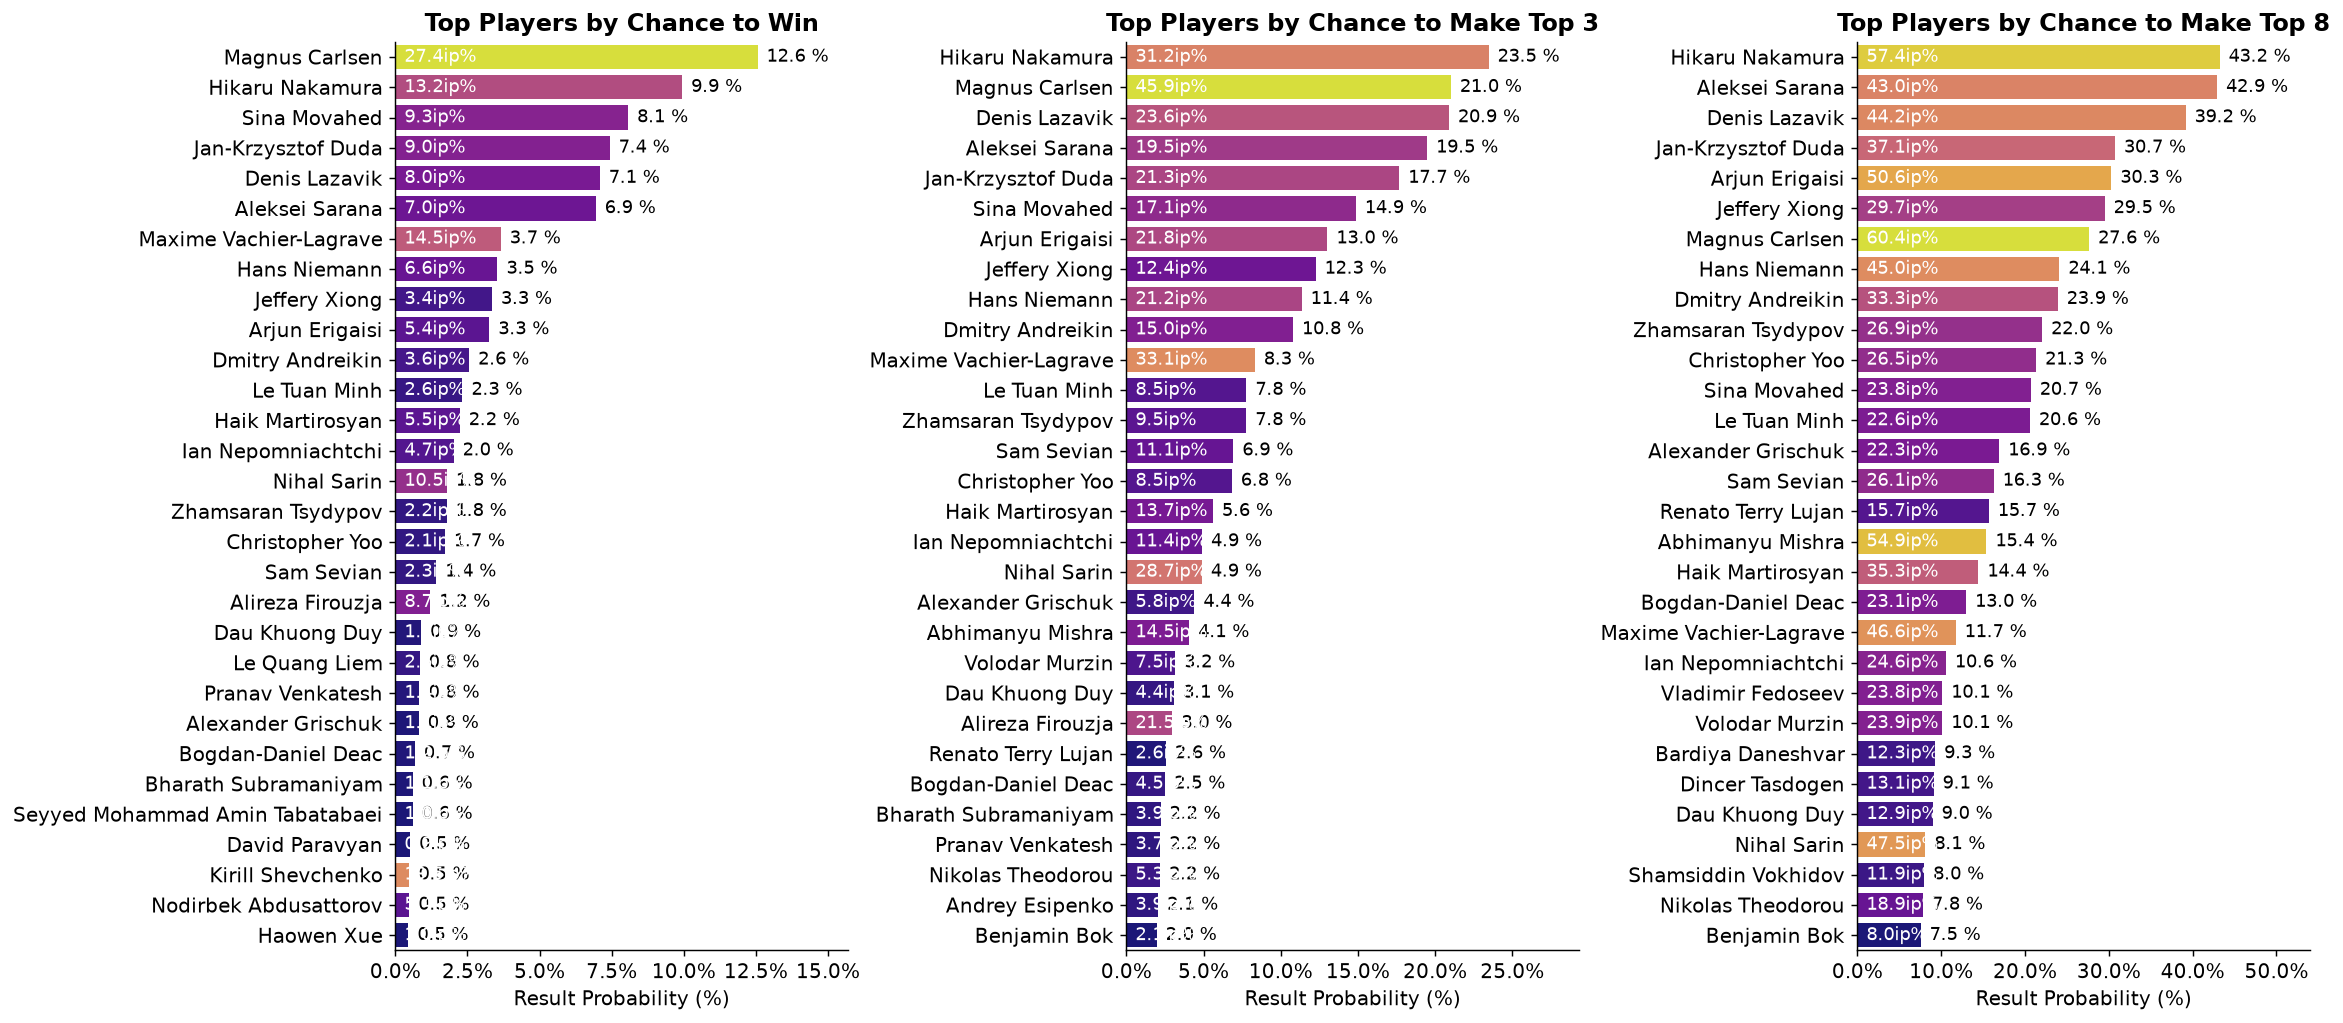

In [13]:
fig, axes = plt.subplots(1,3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    names = [USERNAME_TO_PLAYER.get(username,username) for username in df_plot['username']]

    sns.barplot(data = df_plot, x=col_chance, y=names, ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[col_chance].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Result Probability (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]

        ax.text(width + (max_width * 0.02), y, f'{chance_val*100:.1f} %', va = 'center', ha='left', fontsize=10, color='black')
        ax.text(max_width * 0.02, y, f'{when_val*100:.1f}ip%', va = 'center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()